In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Data not included in repo - see README for sources
df = pd.read_csv('data/dataset.csv', sep=';')
df.replace(',', '.', regex=True, inplace=True)
df = df.astype(float)
df.dropna(inplace=True)
df["log_AgNPs"] = np.log10(df["AgNPs"] + 1e-6)
df.drop(columns=["AgNPs"], inplace=True)
df["logC_x_time"] = df["log_AgNPs"] * df["Incubation [h]"] # intereakcja logC × czas

y = df["Viability [%]"]
X = df[["log_AgNPs", "Incubation [h]", "Drug", "logC_x_time"]]
print(X.shape)
print(y.shape)
df

(50, 4)
(50,)


,Incubation [h],Viability [%],Drug,log_AgNPs,logC_x_time
0,48.0,74.15,0.00,1.397940e+00,67.101121
1,48.0,73.62,0.00,1.698970e+00,81.550561
2,48.0,65.57,0.00,2.000000e+00,96.000000
3,48.0,25.25,0.00,2.301030e+00,110.449440
4,24.0,92.00,0.00,-2.568475e+00,-61.643410
5,24.0,72.00,0.00,-2.267526e+00,-54.420620
6,24.0,50.00,0.00,-1.966536e+00,-47.196865
7,24.0,20.00,0.00,-1.790458e+00,-42.970996
8,24.0,7.00,0.00,-1.665526e+00,-39.972627
9,24.0,84.00,0.00,4.342943e-07,0.000010


In [2]:
model = LinearRegression()
model.fit(X, y)

coef_df = pd.DataFrame({
    "Zmienna": X.columns,
    "Współczynnik": model.coef_
})

coef_df

,Zmienna,Współczynnik
0,log_AgNPs,-11.141833
1,Incubation [h],0.204679
2,Drug,-11.539804
3,logC_x_time,0.109631


In [3]:
y_pred = model.predict(X)

print("R²:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
df["predicted_viability"] = y_pred
df

R²: 0.35689455917486035
RMSE: 24.48807212831071


,Incubation [h],Viability [%],Drug,log_AgNPs,logC_x_time,predicted_viability
0,48.0,74.15,0.00,1.397940e+00,67.101121,52.581026
1,48.0,73.62,0.00,1.698970e+00,81.550561,50.811107
2,48.0,65.57,0.00,2.000000e+00,96.000000,49.041188
3,48.0,25.25,0.00,2.301030e+00,110.449440,47.271270
4,24.0,92.00,0.00,-2.568475e+00,-61.643410,77.747469
5,24.0,72.00,0.00,-2.267526e+00,-54.420620,75.186180
6,24.0,50.00,0.00,-1.966536e+00,-47.196865,72.624550
7,24.0,20.00,0.00,-1.790458e+00,-42.970996,71.126006
8,24.0,7.00,0.00,-1.665526e+00,-39.972627,70.062749
9,24.0,84.00,0.00,4.342943e-07,0.000010,55.887971


In [32]:
def predict_viability(AgNPs_concentration, incubation_time, drug_concentration):
    log_c = np.log10(AgNPs_concentration + 1e-6)
    
    X_new = pd.DataFrame({
        "log_AgNPs": [log_c],
        "Incubation [h]": [incubation_time],
        "Drug": [drug_concentration],
        "logC_x_time": [log_c * incubation_time]
    })
    
    viability = model.predict(X_new)[0]
    viability = max(0, min(100, viability))  # ograniczenie biologiczne
    return viability

pred = predict_viability(AgNPs_concentration=1.1079, incubation_time=24, drug_concentration=0)
print(f"Przewidywana przeżywalność: {pred:.1f}%")


Przewidywana przeżywalność: 55.5%


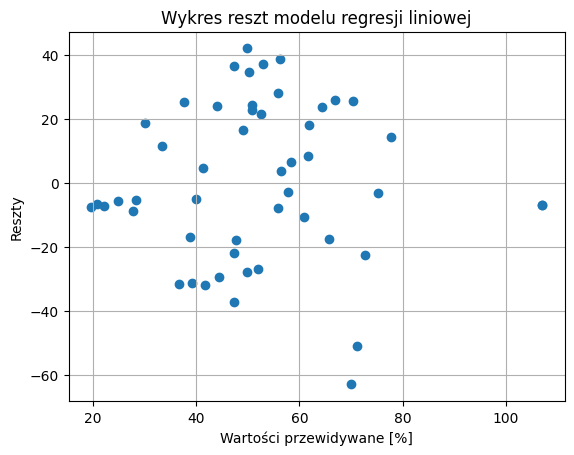

In [74]:
# Predykcja
y_pred = model.predict(X)

# Reszty
residuals = y - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
# plt.axhline(0)
plt.xlabel("Wartości przewidywane [%]")
plt.ylabel("Reszty")
plt.title("Wykres reszt modelu regresji liniowej")
plt.grid(True)
plt.show()

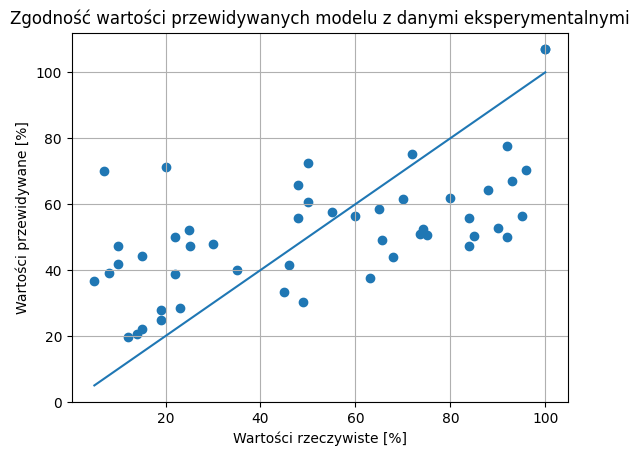

In [76]:
plt.figure()
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Wartości rzeczywiste [%]")
plt.ylabel("Wartości przewidywane [%]")
plt.title("Zgodność wartości przewidywanych modelu z danymi eksperymentalnymi")
plt.grid(True)
plt.show()
